# 百度指数深层探索性数据分析与统计检验
本小节将聚焦大量的统计描述数据、正态性检验以及平稳性检验，提供决定是否进行域变换（如对数变换、Box-Cox、差分等）的数据依据。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
try:
    from statsmodels.tsa.stattools import adfuller
except ImportError:
    adfuller = None
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

file_path = r'd:\data\time-llm-rework\Time-LLM\my_data_pure\百度指数_daily_merge_tiantan_20220601_20260131.csv'
df = pd.read_csv(file_path)
df['日期'] = pd.to_datetime(df['日期'])
cols = ['PC+移动指数', '移动指数', 'PC指数']
df.head()

,关键词,城市代码,城市,日期,数据类型,数据间隔(天),所属年份,PC+移动指数,移动指数,PC指数,爬取时间
0,天坛,0,全国,2022-06-01,日度,1,2022,1358,958,400,2026-03-27 22:04:22
1,天坛,0,全国,2022-06-02,日度,1,2022,1386,938,448,2026-03-27 22:04:22
2,天坛,0,全国,2022-06-03,日度,1,2022,1299,981,318,2026-03-27 22:04:22
3,天坛,0,全国,2022-06-04,日度,1,2022,1433,1124,309,2026-03-27 22:04:22
4,天坛,0,全国,2022-06-05,日度,1,2022,1674,1305,369,2026-03-27 22:04:22


## 1. 基础描述性统计与方差分析
提供均值、标准差、离散程度以及丰富的百分位数，用于发现数据的基本范围和极值问题。

In [2]:
desc_stats = df[cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T
desc_stats['方差(var)'] = df[cols].var()
desc_stats['变异系数(CV)'] = desc_stats['std'] / desc_stats['mean'] # 衡量数据的相对离散程度
desc_stats['极差'] = desc_stats['max'] - desc_stats['min']
desc_stats

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max,方差(var),变异系数(CV),极差
PC+移动指数,1341.0,1697.018643,569.378931,861.0,962.4,1108.0,1307.0,1530.0,1974.0,2413.0,2762.0,3557.4,8705.0,324192.367563,0.335517,7844.0
移动指数,1341.0,1322.653990,527.986063,671.0,750.6,874.0,962.0,1132.0,1543.0,1976.0,2355.0,3225.2,7355.0,278769.283173,0.399187,6684.0
PC指数,1341.0,374.364653,129.570826,112.0,144.8,186.0,274.0,361.0,468.0,544.0,586.0,688.8,1350.0,16788.599018,0.346109,1238.0


## 2. 数据分布形态检验 (偏度、峰度与正态性检验)
数据变形的核心参考：
- **偏度 (Skewness)**：衡量分布不对称性。>0为右偏(长尾在右侧，需要log变换使呈正态)，<0为左偏。
- **峰度 (Kurtosis)**：衡量尖峰程度。常态分布峰度偏离为0，>0表示尖峰厚尾 (极值多变)。
- **Shapiro-Wilk 检验**：P-value < 0.05 拒绝原假设，说明**不服从正态分布**。如果不服从正态分布且重尾，通常建议做 Log 或者 Box-Cox 变换。

In [3]:
normality_results = []
for col in cols:
    kurtosis = df[col].kurt()
    skewness = df[col].skew()
    stat, p = stats.shapiro(df[col].dropna())
    normality_results.append({
        '特征 (Feature)': col,
        '偏度 (Skewness)': skewness,
        '峰度 (Kurtosis)': kurtosis,
        'Shapiro W 统计量': stat,
        'Shapiro P-value': p,
        '服从正态分布?': '是' if p > 0.05 else '否 (拒绝原假设)'
    })
pd.DataFrame(normality_results)

,特征 (Feature),偏度 (Skewness),峰度 (Kurtosis),Shapiro W 统计量,Shapiro P-value,服从正态分布?
0,PC+移动指数,2.565492,18.803869,0.837372,6.381580e-35,否 (拒绝原假设)
1,移动指数,2.692093,16.010604,0.778026,3.105343e-39,否 (拒绝原假设)
2,PC指数,0.635454,1.761136,0.969784,3.971431e-16,否 (拒绝原假设)


## 3. 平稳性检验 (ADF Test)
对时间序列进行平稳性检验。P-value < 0.05 表示拒绝原假设，序列是**平稳的**。
- 若不平稳（p > 0.05），模型训练前大概率需要进行**一阶差分**或者去除趋势项以达到平稳。

In [4]:
adf_results = []
if adfuller is not None:
    for col in cols:
        result = adfuller(df[col].dropna())
        adf_results.append({
            '特征 (Feature)': col,
            'ADF 统计量': result[0],
            'P-value': result[1],
            '1% 临界值': result[4]['1%'],
            '5% 临界值': result[4]['5%'],
            '10% 临界值': result[4]['10%'],
            '是否平稳?': '是 (平稳序列)' if result[1] < 0.05 else '否 (需要差分等域变换)'
        })
    display(pd.DataFrame(adf_results))
else:
    print("未检测到 statsmodels 库，跳过平稳性检验。你可以通过 pip install statsmodels 安装后运行此代码格。")

,特征 (Feature),ADF 统计量,P-value,1% 临界值,5% 临界值,10% 临界值,是否平稳?
0,PC+移动指数,-3.684148,0.004342,-3.435287,-2.863720,-2.567931,是 (平稳序列)
1,移动指数,-3.924464,0.001862,-3.435321,-2.863735,-2.567939,是 (平稳序列)
2,PC指数,-2.117971,0.237350,-3.435321,-2.863735,-2.567939,否 (需要差分等域变换)


## 4. 滚动波动率统计 (检查方差非齐性 / 异方差)
我们将计算 30天 以及 90天 滚动标准差的最大与最小比值。如果不同时期的标准差相差极大，说明存在**异方差性**（方差随时间剧烈变化），此时必须要应用**Log 变换或 Box-Cox 变换**来稳定方差。

In [5]:
var_hetero_results = []
for col in cols:
    roll_30_std = df[col].rolling(30).std().dropna()
    roll_90_std = df[col].rolling(90).std().dropna()
    
    var_hetero_results.append({
        '特征 (Feature)': col,
        '30天滚动标准差极差比 (Max/Min)': roll_30_std.max() / (roll_30_std.min() + 1e-5),
        '90天滚动标准差极差比 (Max/Min)': roll_90_std.max() / (roll_90_std.min() + 1e-5),
    })
    
vdf = pd.DataFrame(var_hetero_results)
display(vdf)

,特征 (Feature),30天滚动标准差极差比 (Max/Min),90天滚动标准差极差比 (Max/Min)
0,PC+移动指数,49.102865,11.682406
1,移动指数,47.866476,12.394976
2,PC指数,5.502082,2.708218


## 5. 补充图表（辅助肉眼观察数据状态）
结合以上数据查看分布的真实形态

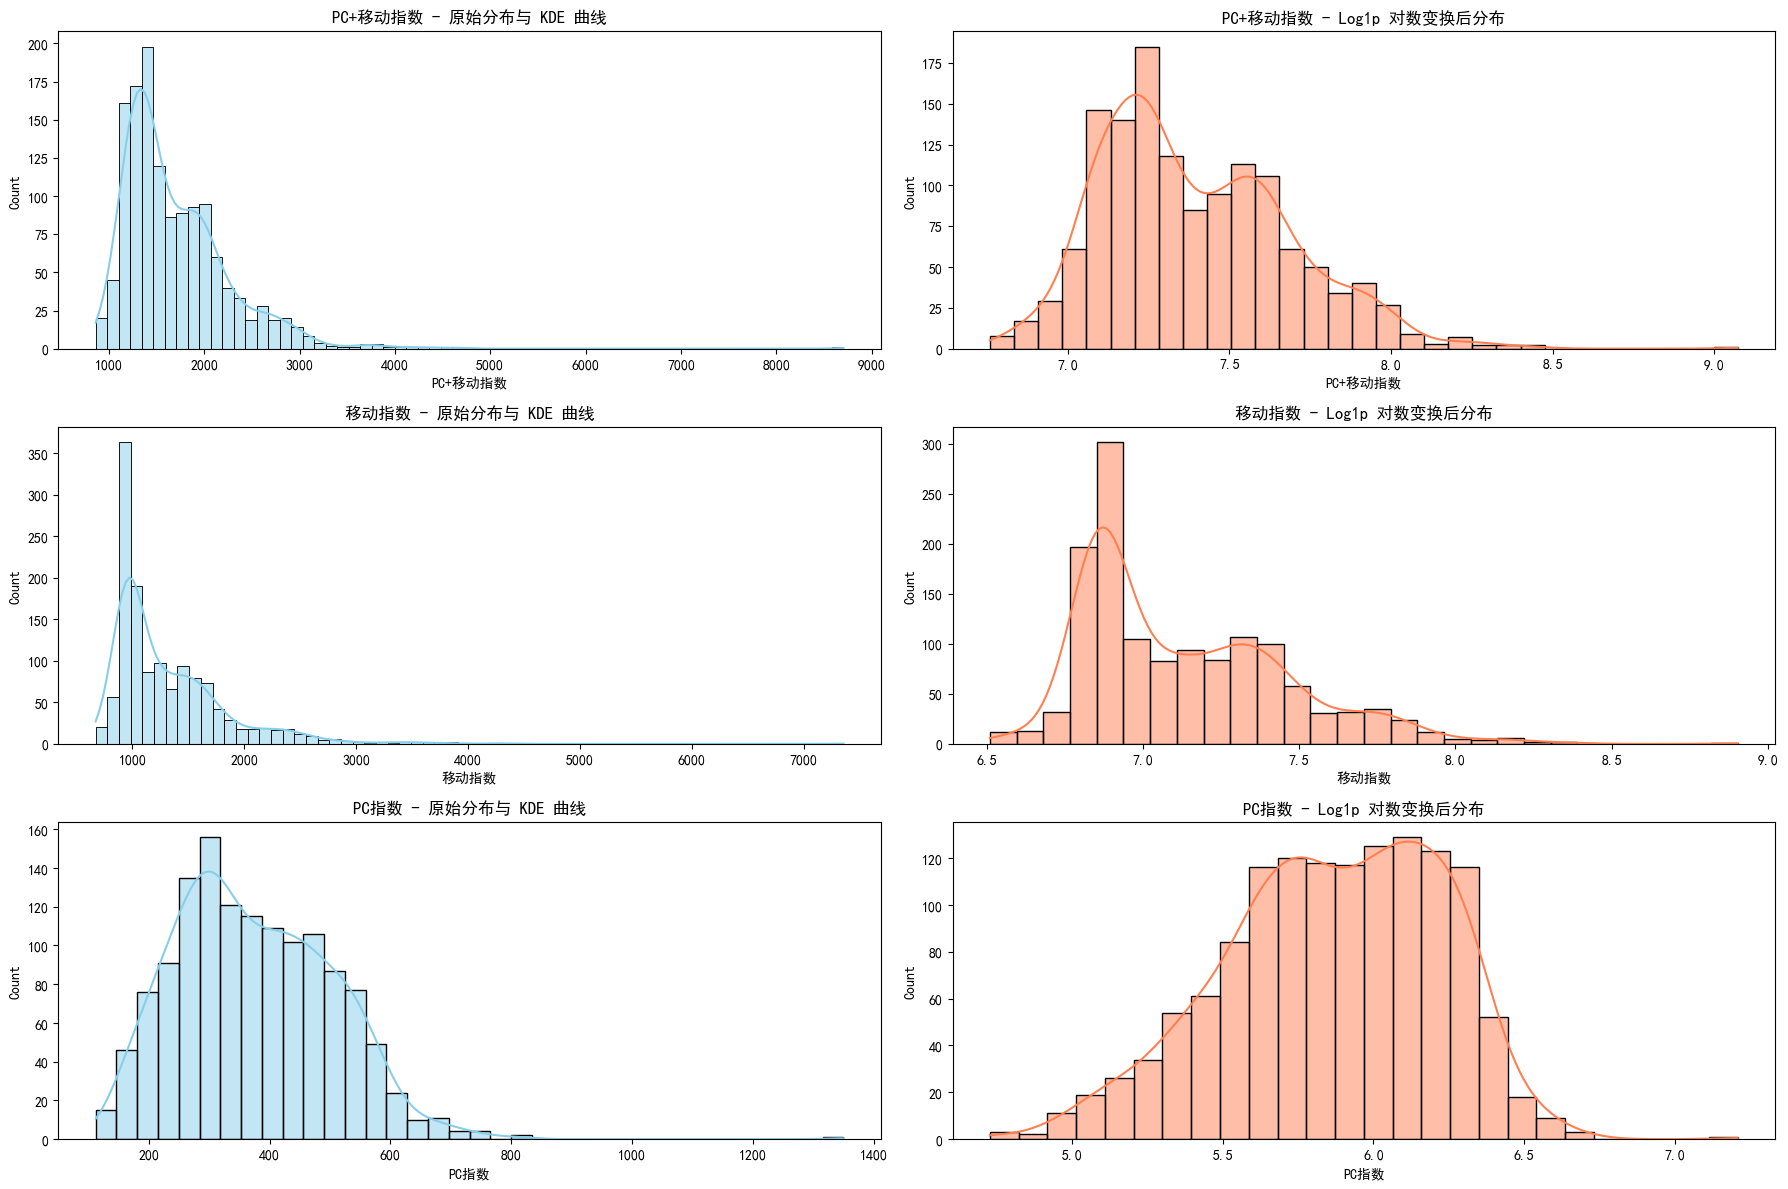

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
for i, col in enumerate(cols):
    # 分析原始分布图
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} - 原始分布与 KDE 曲线', fontsize=12)
    
    # 绘制 Log 变换后的分布图（用于观察对数变换的修复作用）
    sns.histplot(np.log1p(df[col]), kde=True, ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'{col} - Log1p 对数变换后分布', fontsize=12)
    
plt.tight_layout()
plt.show()